# Import Libs

In [40]:
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix)
import numpy as np, pandas as pd, torch
import os, gc
import random


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [2]:
max_seq_length = 128 #Max token from each diary

In [3]:

def set_seed(seed=None, seed_torch=True):
  """
  Function that controls randomness. NumPy and random modules must be imported.

  Args:
    seed : Integer
      A non-negative integer that defines the random state. Default is `None`.
    seed_torch : Boolean
      If `True` sets the random seed for pytorch tensors, so pytorch module
      must be imported. Default is `True`.

  Returns:
    Nothing.
  """
  if seed is None:
    seed = np.random.choice(2 ** 32)
  random.seed(seed)
  np.random.seed(seed)
  if seed_torch:
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

  print(f'Random seed {seed} has been set.')

# In case that `DataLoader` is used
def seed_worker(worker_id):
  """
  DataLoader will reseed workers following randomness in
  multi-process data loading algorithm.

  Args:
    worker_id: integer
      ID of subprocess to seed. 0 means that
      the data will be loaded in the main process
      Refer: https://pytorch.org/docs/stable/data.html#data-loading-randomness for more details

  Returns:
    Nothing
  """
  worker_seed = torch.initial_seed() % 2**32
  np.random.seed(worker_seed)
  random.seed(worker_seed)

def set_device():
    """Return torch.device and print how many GPUs are visible."""
    if torch.cuda.is_available():
        n = torch.cuda.device_count()
        print(f"✓ {n} CUDA device(s) detected")
        return torch.device("cuda")
    print("⚠️  No GPU detected – falling back to CPU")
    return torch.device("cpu")

SEED = 2025
set_seed(seed=SEED)
device = set_device()

Random seed 2025 has been set.
✓ 1 CUDA device(s) detected


#  Import & Preprocess Data

In [4]:
# -------------------------------------------------------------
# 1.  Prepare labels (same mapping as before)
# -------------------------------------------------------------
# @title Load the dataset
url = 'https://raw.githubusercontent.com/pinchunc/NMA_DL_SentimentAnalysis/main/data/hippoCorpusV2.csv'
df_dataset = pd.read_csv(url)

# @title filter for recalled memtype
df_dataset = df_dataset[df_dataset['memType'] == 'recalled']

df_bt = df_dataset.copy()
map_  = {1:"Low", 2:"-", 3:"High", 4:"High", 5:"High"}
df_bt["stressful"] = df_bt["stressful"].map(map_)
df_bt = df_bt[df_bt["stressful"] != "-"]

docs   = df_bt["story"].tolist()
labels = df_bt["stressful"].tolist()
lbl2id = {lbl: i for i, lbl in enumerate(sorted(set(labels)))}
y      = np.array([lbl2id[l] for l in labels])

# -------------------------------------------------------------
# 2.  Train / test split
# -------------------------------------------------------------
docs_train, docs_dummy, y_train, y_dummy = train_test_split(
    docs, y, test_size=0.2, random_state=SEED, stratify=y)
docs_val, docs_test, y_val, y_test = train_test_split(
    docs_dummy, y_dummy, test_size=0.5, random_state=SEED, stratify=y_dummy)

# Embedding

    "sentence-transformers/all-MiniLM-L6-v2",   # 384‑d
    "sentence-transformers/all-MiniLM-L12-v2",  # 384‑d
    "sentence-transformers/all-mpnet-base-v2",  # 768‑d
    "intfloat/e5-base-v2",                       # 768‑d, good for retrieval
    "Qwen/Qwen3-Embedding-4B",
    "google/bert_uncased_L-2_H-128_A-2"

In [19]:
EMBED_MODEL_NAMES = [
    "Qwen/Qwen3-Embedding-4B",
    "sentence-transformers/all-mpnet-base-v2",
    "google/bert_uncased_L-12_H-768_A-12"
]
PCA_DIM = 10000 #256           # common dimensionality for TinyMLP input
RESULT_DIR = "results"  # where the JSON logs will be written
CLASS_NAMES = [k for k, _ in sorted(lbl2id.items())]

'''def google_small_name(L, H):      # A = H//64 in Google’s naming scheme
    return f"google/bert_uncased_L-{L}_H-{H}_A-{H//64}"

tiny_name = google_small_name(2,128)                       # BERT‑tiny
mini_name = google_small_name(4,256)                       # BERT‑mini
medium_name = google_small_name(8,512)                       # BERT‑medium
base_name = google_small_name(12,768)                       # BERT‑base

EMBED_MODEL_NAMES += [tiny_name, mini_name, medium_name, base_name]
print(EMBED_MODEL_NAMES)'''

'def google_small_name(L, H):      # A\xa0=\xa0H//64 in Google’s naming scheme\n    return f"google/bert_uncased_L-{L}_H-{H}_A-{H//64}"\n\ntiny_name = google_small_name(2,128)                       # BERT‑tiny\nmini_name = google_small_name(4,256)                       # BERT‑mini\nmedium_name = google_small_name(8,512)                       # BERT‑medium\nbase_name = google_small_name(12,768)                       # BERT‑base\n\nEMBED_MODEL_NAMES += [tiny_name, mini_name, medium_name, base_name]\nprint(EMBED_MODEL_NAMES)'

# Classify with a neural net

In [13]:
import os, json, time, numpy as np, torch, torch.nn as nn
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.utils import compute_class_weight
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from torch.utils.data import TensorDataset, DataLoader
from transformers import get_linear_schedule_with_warmup
from sentence_transformers import SentenceTransformer

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
os.makedirs(RESULT_DIR, exist_ok=True)

class TinyMLP(nn.Module):
    def __init__(self, in_dim, hidden_dims=[128, 32], n_classes=2, p_drop=0.2):
        super().__init__()
        dims = [in_dim] + hidden_dims
        layers = []
        for d_in, d_out in zip(dims[:-1], dims[1:]):
            layers += [nn.Linear(d_in, d_out), nn.ReLU(), nn.Dropout(p_drop)]
        layers += [nn.Linear(dims[-1], n_classes)]
        self.net = nn.Sequential(*layers)

    def forward(self, x): return self.net(x)
    
def get_embedder(model_name, dtype=torch.float16, max_seq_length=max_seq_length):
    """
    Load SentenceTransformer with optional fp16/8-bit, and custom max input length.
    """
    model_kwargs = {
        "device_map": "auto",
        "torch_dtype": dtype
    }

    model = SentenceTransformer(
        model_name,
        device="cuda" if torch.cuda.is_available() else "cpu",
        model_kwargs=model_kwargs,
        trust_remote_code=True
    )

    # Set shorter max sequence length (e.g., 256 tokens)
    model.max_seq_length = max_seq_length

    return model

'''def get_embedder(model_name, dtype=torch.float16):
    """
    Load a model in fp16 (or 8‑bit) and put as much as possible on the GPU.
    """
    return SentenceTransformer(
        model_name,
        device="cuda" if torch.cuda.is_available() else "cpu",
        trust_remote_code=True                 # Qwen models need this
        #model_kwargs={
        #    "device_map": "auto",               # let HF spread layers if needed
        #    "torch_dtype": dtype               # fp16 halves the weight memory
        #    # "load_in_8bit": True             # <- uncomment for 8‑bit (needs bitsandbytes)
        #},
    )'''

'def get_embedder(model_name, dtype=torch.float16):\n    """\n    Load a model in fp16 (or 8‑bit) and put as much as possible on the GPU.\n    """\n    return SentenceTransformer(\n        model_name,\n        device="cuda" if torch.cuda.is_available() else "cpu",\n        trust_remote_code=True                 # Qwen models need this\n        #model_kwargs={\n        #    "device_map": "auto",               # let HF spread layers if needed\n        #    "torch_dtype": dtype               # fp16 halves the weight memory\n        #    # "load_in_8bit": True             # <- uncomment for 8‑bit (needs bitsandbytes)\n        #},\n    )'

In [14]:
import os, gc, json, pickle, numpy as np, torch
from pathlib import Path
from sklearn.decomposition import PCA

EMBED_OUT_DIR = Path("embeddings")
EMBED_OUT_DIR.mkdir(exist_ok=True)

def embed_and_save(model_name, docs_train, docs_val, docs_test,
                   pca_dim=PCA_DIM, batch_size=8):
    """
    Encode → optional PCA → save to disk.
    If pca_dim > model_hidden or pca_dim == model_hidden, we auto‑shrink or skip PCA.
    """
    safe = model_name.split("/")[-1].replace("-", "_")
    out_npz = EMBED_OUT_DIR / f"{safe}_pca{pca_dim}.npz"
    out_pkl = EMBED_OUT_DIR / f"{safe}_pca{pca_dim}.pkl"

    if out_npz.exists():
        print(f"✓ embeddings for {model_name} already on disk")
        return

    print(f"⏳ encoding {model_name} …")
    embedder = get_embedder(model_name)
    hidden_size = embedder.get_sentence_embedding_dimension()
    X_tr = embedder.encode(docs_train, batch_size=batch_size,
                           show_progress_bar=True, convert_to_numpy=True)
    X_vl = embedder.encode(docs_val, batch_size=batch_size,
                           show_progress_bar=True, convert_to_numpy=True)
    X_te = embedder.encode(docs_test,  batch_size=batch_size,
                           show_progress_bar=True, convert_to_numpy=True)

    embedder.to("cpu"); del embedder
    torch.cuda.empty_cache(); gc.collect()

    # ------------ PCA logic ------------
    eff_dim = min(pca_dim, hidden_size)
    if eff_dim < hidden_size:
        print(f"⚙️  PCA: {hidden_size} → {eff_dim}")
        pca = PCA(n_components=eff_dim, random_state=42)
        X_tr = pca.fit_transform(X_tr)
        X_vl = pca.transform(X_vl)
        X_te = pca.transform(X_te)
    else:
        print(f"⚙️  PCA skipped (requested {pca_dim}, hidden={hidden_size})")
        pca = None  # identity

    np.savez_compressed(out_npz, X_tr=X_tr, X_vl=X_vl, X_te=X_te)
    with open(out_pkl, "wb") as fh:
        pickle.dump(pca, fh)

    print(f"✅ saved to {out_npz}  ({X_tr.shape[1]}‑d)")


In [21]:
for m in EMBED_MODEL_NAMES:
    bs = 32 if "L-12_H-768_A-12" in m or "Qwen/Qwen3" in m else 128
    embed_and_save(m, docs_train, docs_val, docs_test, batch_size=bs)
    print(f"✓ finished {m}  (batch_size={bs})")

✓ embeddings for Qwen/Qwen3-Embedding-4B already on disk
✓ finished Qwen/Qwen3-Embedding-4B  (batch_size=32)
⏳ encoding sentence-transformers/all-mpnet-base-v2 …


special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/15 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

Batches:   0%|          | 0/57 [00:00<?, ?it/s]

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

⚙️  PCA skipped (requested 10000, hidden=768)
✅ saved to embeddings/bert_uncased_L_12_H_768_A_12_pca10000.npz  (768‑d)
✓ finished google/bert_uncased_L-12_H-768_A-12  (batch_size=32)


In [22]:
import matplotlib.pyplot as plt     # you already have this elsewhere
import re

PLT_OUT_DIR = Path("plots")
PLT_OUT_DIR.mkdir(exist_ok=True)

def safe_filename(text):
    """Sanitize string to be safe for filenames."""
    return re.sub(r"[^\w\-_\.]", "_", text)  # replace anything not alphanum/_/./- with _


def plot_history(hist, title_prefix=""):
    """Plot train/val loss and accuracy curves and save to disk."""
    fname_prefix = safe_filename(title_prefix)
    
    plt.figure(figsize=(6, 4))
    plt.plot(hist["tr_loss"], label="Train loss")
    plt.plot(hist["val_loss"], label="Val loss")
    plt.xlabel("Epoch"); plt.ylabel("Cross‑entropy loss")
    plt.title(f"{title_prefix} – loss"); plt.legend(); plt.tight_layout()
    plt.savefig(f"plots/{fname_prefix}_loss.png", dpi=300, bbox_inches='tight')
    plt.show()

    # Accuracy ----------------------------------------------
    plt.figure(figsize=(6, 4))
    plt.plot(hist["tr_acc"], label="Train acc")
    plt.plot(hist["val_acc"], label="Val acc")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy")
    plt.title(f"{title_prefix} – accuracy"); plt.legend(); plt.tight_layout()
    plt.savefig(f"plots/{fname_prefix}_accuracy.png", dpi=300, bbox_inches='tight')
    plt.show()

def show_test_report(log, class_names):
    """
    Pretty‑print accuracy & classification‑report table,
    and plot a confusion‑matrix heat‑map.
    """
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt

    # -------- text summary ----------
    acc = log["test_metrics"]["accuracy"]
    print(f"Accuracy: {acc:.3f} | {log['epochs_run']}\n")

    report_df = pd.DataFrame(log["test_metrics"]["classification_report"]).T
    print("Classification Report")
    print(report_df.round(3))
    print("\nConfusion Matrix")

    # -------- heat‑map ----------
    cm = np.array(log["test_metrics"]["confusion_matrix"])
    print(cm)                              # plain text for reference



In [23]:
def train_from_saved(model_name, y_train, y_val, y_test,
                     pca_dim=PCA_DIM, batch_size=128,
                     epochs=300, warmup_pct=0.03,
                     patience=40, lr=3e-5):

    safe = model_name.split("/")[-1].replace("-", "_")
    data = np.load(EMBED_OUT_DIR / f"{safe}_pca{pca_dim}.npz")
    X_tr, X_vl, X_te = data["X_tr"], data["X_vl"], data["X_te"]

    # -------------- torch tensors & loaders -----------------
    X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
    X_vl_t = torch.tensor(X_vl, dtype=torch.float32)
    X_te_t = torch.tensor(X_te, dtype=torch.float32)
    y_tr_t = torch.tensor(y_train, dtype=torch.long)
    y_vl_t = torch.tensor(y_val,   dtype=torch.long)
    y_te_t = torch.tensor(y_test,  dtype=torch.long)

    train_dl = DataLoader(TensorDataset(X_tr_t, y_tr_t),
                          batch_size=batch_size, shuffle=True)
    valid_dl  = DataLoader(TensorDataset(X_vl_t, y_vl_t),
                          batch_size=4*batch_size, shuffle=False)
    test_dl  = DataLoader(TensorDataset(X_te_t, y_te_t),
                          batch_size=4*batch_size, shuffle=False)

    # -------------- model, scheduler, early‑stop ------------
    model = TinyMLP(in_dim=X_tr.shape[1]).to(DEVICE)
    cls_w = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
    criterion = nn.CrossEntropyLoss(weight=torch.tensor(cls_w, dtype=torch.float32, device=DEVICE))
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    total_steps = len(train_dl) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(warmup_pct * total_steps),
        num_training_steps=total_steps
    )

    # ----- helpers -----
    def train_epoch():
        model.train(); tot=correct=loss_sum=0
        for xb,yb in train_dl:
            xb,yb=xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb); loss.backward()
            optimizer.step(); scheduler.step()
            loss_sum += loss.item()*len(xb)
            correct  += (model(xb).argmax(1)==yb).sum().item(); tot+=len(xb)
        return loss_sum/tot, correct/tot

    def eval_epoch():
        model.eval(); tot=correct=loss_sum=0
        with torch.no_grad():
            for xb,yb in valid_dl:
                xb,yb = xb.to(DEVICE), yb.to(DEVICE)
                out = model(xb)
                loss_sum += criterion(out,yb).item()*len(xb)
                correct  += (out.argmax(1)==yb).sum().item(); tot+=len(xb)
        return loss_sum/tot, correct/tot

    # ----- train loop -----
    h = {k:[] for k in ["tr_loss","val_loss","tr_acc","val_acc"]}
    best_val=1e9; wait=0; best_state=None
    for ep in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch()
        val_loss, val_acc = eval_epoch()
    
        h["tr_loss" ].append(tr_loss)
        h["val_loss"].append(val_loss)
        h["tr_acc" ].append(tr_acc)
        h["val_acc"].append(val_acc)
    
        if val_loss < best_val - 1e-3:
            best_val, best_state, wait = val_loss, model.state_dict(), 0
        else:
            wait += 1
            if wait >= patience:
                break

    if best_state: model.load_state_dict(best_state)

    # ----- test -----
    model.eval(); preds=[]
    with torch.no_grad():
        for xb,_ in test_dl:
            preds.append(model(xb.to(DEVICE)).argmax(1).cpu())
    y_pred = torch.cat(preds).numpy()

    metrics = {
        "accuracy": float(accuracy_score(y_test,y_pred)),
        "classification_report": classification_report(
            y_test,y_pred,target_names=[k for k,_ in sorted(lbl2id.items())],
            output_dict=True,zero_division=0),
        "confusion_matrix": confusion_matrix(y_test,y_pred).tolist()
    }

    log = {
        "embed_model": model_name,
        "pca_dim": pca_dim,
        "epochs_run": len(h["tr_loss"]),
        "history": h,
        "test_metrics": metrics
    }
    return log



=== Qwen/Qwen3-Embedding-4B ===


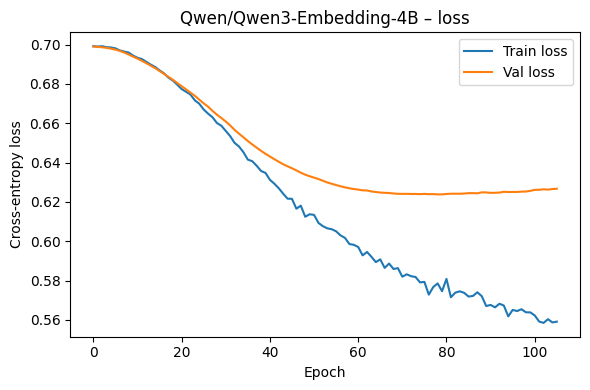

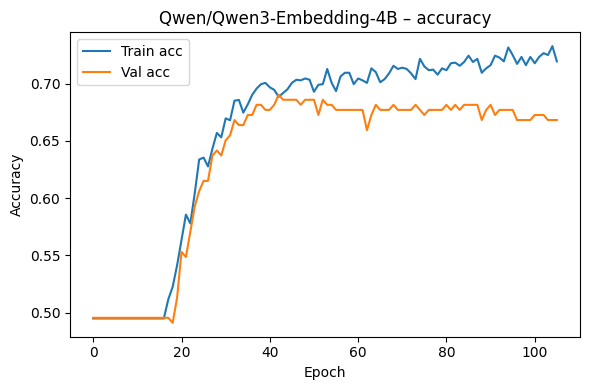

Accuracy: 0.683 | 106

Classification Report
              precision  recall  f1-score  support
High              0.689   0.652     0.670  112.000
Low               0.678   0.713     0.695  115.000
accuracy          0.683   0.683     0.683    0.683
macro avg         0.683   0.682     0.682  227.000
weighted avg      0.683   0.683     0.682  227.000

Confusion Matrix
[[73 39]
 [33 82]]

=== sentence-transformers/all-mpnet-base-v2 ===


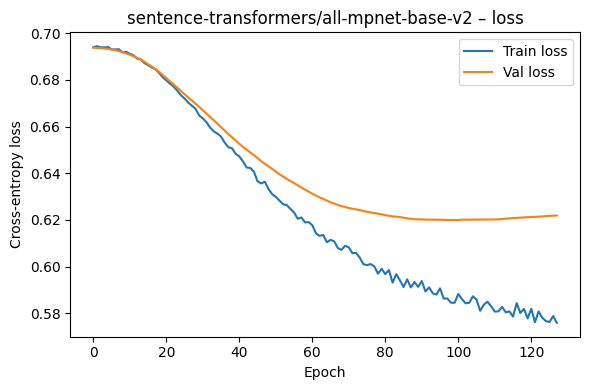

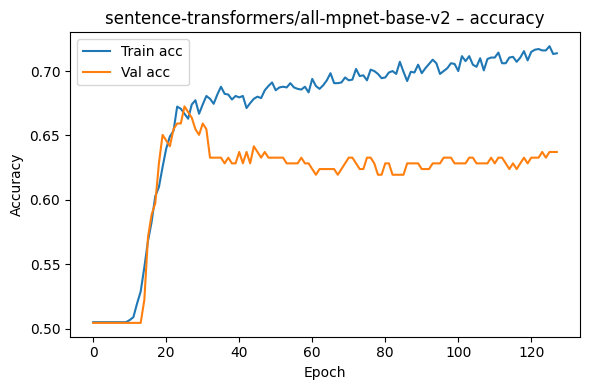

Accuracy: 0.705 | 128

Classification Report
              precision  recall  f1-score  support
High              0.710   0.679     0.694  112.000
Low               0.700   0.730     0.715  115.000
accuracy          0.705   0.705     0.705    0.705
macro avg         0.705   0.705     0.704  227.000
weighted avg      0.705   0.705     0.705  227.000

Confusion Matrix
[[76 36]
 [31 84]]

=== google/bert_uncased_L-12_H-768_A-12 ===


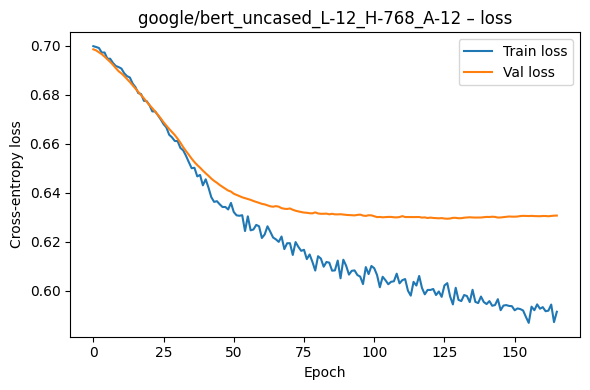

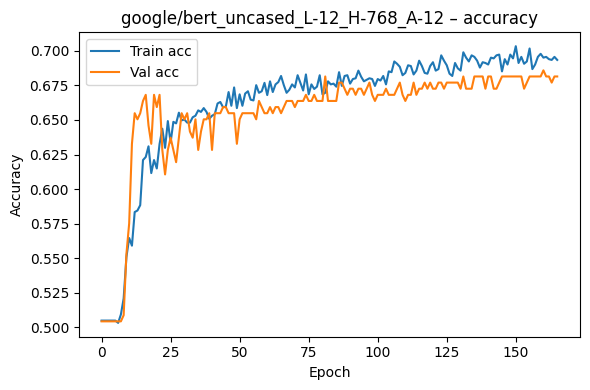

Accuracy: 0.639 | 166

Classification Report
              precision  recall  f1-score  support
High              0.627   0.661     0.643  112.000
Low               0.651   0.617     0.634  115.000
accuracy          0.639   0.639     0.639    0.639
macro avg         0.639   0.639     0.639  227.000
weighted avg      0.639   0.639     0.639  227.000

Confusion Matrix
[[74 38]
 [44 71]]


In [24]:
all_logs=[]
for m in EMBED_MODEL_NAMES:
    print(f"\n=== {m} ===")
    log = train_from_saved(m, y_train, y_val, y_test)
    all_logs.append(log)
    plot_history(log["history"], title_prefix=m)
    show_test_report(log, CLASS_NAMES)

# Classify with SVC and LogisticRegression

In [38]:
pca_dim = 10000

In [39]:
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.svm import SVC 

from sklearn.preprocessing import FunctionTransformer, StandardScaler


from sklearn.utils import compute_class_weight
from transformers import get_linear_schedule_with_warmup  # NEW

classes = np.unique(y_train)
weights_arr  = compute_class_weight("balanced",
                              classes=classes,
                              y=y_train)
class_w  = torch.tensor(weights_arr, dtype=torch.float32).to(DEVICE)
class_w_dict   = dict(zip(classes, weights_arr))

for model_name in EMBED_MODEL_NAMES:
    print("="*20, model_name, "="*20)
    pca_dim = pca_dim
    safe = model_name.split("/")[-1].replace("-", "_")
    data = np.load(EMBED_OUT_DIR / f"{safe}_pca{pca_dim}.npz")
    X_tr, X_vl, X_te = data["X_tr"], data["X_vl"], data["X_te"]
    pipe_svm = Pipeline([
        ("pca", PCA(n_components=80, random_state=2025)),
        ("clf", SVC(kernel="rbf",
                    class_weight=class_w_dict,
                    probability=True))
    ])
    pipe_svm.fit(X_tr, y_train)
    y_pred = pipe_svm.predict(X_te)
    print("LR + PCA accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report")
    print(classification_report(y_test, y_pred,
                                target_names=[k for k,_ in sorted(lbl2id.items(), key=lambda x:x[1])]))
    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, y_pred))


for model_name in EMBED_MODEL_NAMES:
    print("="*20, model_name, "="*20)

    # choose input dimensionality
    pca_dim = pca_dim
    safe     = model_name.split("/")[-1].replace("-", "_")
    data     = np.load(EMBED_OUT_DIR / f"{safe}_pca{pca_dim}.npz")
    X_tr, X_vl, X_te = data["X_tr"], data["X_vl"], data["X_te"]

    pipe_lr = Pipeline([
        ("pca", PCA(n_components=80, random_state=2025)),
        ("clf", LogisticRegression(
            class_weight=class_w_dict,
            max_iter=1000,              # raise if you see a convergence warning
            n_jobs=-1                   # parallelise the underlying linear algebra
        ))
    ])

    pipe_lr.fit(X_tr, y_train)
    y_pred = pipe_lr.predict(X_te)

    print("LogReg + PCA accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report")
    print(classification_report(
        y_test, y_pred,
        target_names=[k for k,_ in sorted(lbl2id.items(), key=lambda x: x[1])]
    ))
    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, y_pred))

==================== Qwen/Qwen3-Embedding-4B ====================
LR + PCA accuracy: 0.6872246696035242

Classification Report
              precision    recall  f1-score   support

        High       0.70      0.65      0.67       112
         Low       0.68      0.72      0.70       115

    accuracy                           0.69       227
   macro avg       0.69      0.69      0.69       227
weighted avg       0.69      0.69      0.69       227


Confusion Matrix
[[73 39]
 [32 83]]
==================== sentence-transformers/all-mpnet-base-v2 ====================
LR + PCA accuracy: 0.6872246696035242

Classification Report
              precision    recall  f1-score   support

        High       0.70      0.65      0.67       112
         Low       0.68      0.72      0.70       115

    accuracy                           0.69       227
   macro avg       0.69      0.69      0.69       227
weighted avg       0.69      0.69      0.69       227


Confusion Matrix
[[73 39]
 [32 83]]
==